Data Cleaning

Data Cleaning means fixing problems in the dataset before training a Machine Learning model.

Common problems:
- Missing values
- Duplicate rows
- Wrong data types
- Outliers

We will use a simple example dataset.

In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Create simple example dataset
data = {
    "Name": ["A", "B", "C", "D", "E", "E"],
    "Age": [22, 25, np.nan, 40, 100, 100],   # missing value + outlier
    "Salary": [20000, 25000, 30000, np.nan, 50000, 50000],
    "Join_Date": ["2022-01-01", "2021-05-10", "2020-03-15", "2022-07-20", "2019-11-11", "2019-11-11"]
}

df = pd.DataFrame(data)
df

,Name,Age,Salary,Join_Date
0,A,22.0,20000.0,2022-01-01
1,B,25.0,25000.0,2021-05-10
2,C,NaN,30000.0,2020-03-15
3,D,40.0,NaN,2022-07-20
4,E,100.0,50000.0,2019-11-11
5,E,100.0,50000.0,2019-11-11


In [3]:
# Drop Rows with Missing Values
df_drop = df.dropna()
df_drop

,Name,Age,Salary,Join_Date
0,A,22.0,20000.0,2022-01-01
1,B,25.0,25000.0,2021-05-10
4,E,100.0,50000.0,2019-11-11
5,E,100.0,50000.0,2019-11-11


In [4]:
#Fill with Mean / Median using SimpleImputer
from sklearn.impute import SimpleImputer

# Mean Imputer for Age
mean_imputer = SimpleImputer(strategy="mean")
df["Age"] = mean_imputer.fit_transform(df[["Age"]])

# Median Imputer for Salary
median_imputer = SimpleImputer(strategy="median")
df["Salary"] = median_imputer.fit_transform(df[["Salary"]])

df

,Name,Age,Salary,Join_Date
0,A,22.0,20000.0,2022-01-01
1,B,25.0,25000.0,2021-05-10
2,C,57.4,30000.0,2020-03-15
3,D,40.0,30000.0,2022-07-20
4,E,100.0,50000.0,2019-11-11
5,E,100.0,50000.0,2019-11-11


In [5]:
#Remove duplicates:
df_no_duplicates = df.drop_duplicates()
df_no_duplicates

,Name,Age,Salary,Join_Date
0,A,22.0,20000.0,2022-01-01
1,B,25.0,25000.0,2021-05-10
2,C,57.4,30000.0,2020-03-15
3,D,40.0,30000.0,2022-07-20
4,E,100.0,50000.0,2019-11-11


In [7]:
#Fix Incorrect Data Types
#Sometimes data types are incorrect:
#- object → int
#- string → datetime


#Convert Object to Integer
df["Age"] = df["Age"].astype(int)

#Convert String to Datetime
df["Join_Date"] = pd.to_datetime(df["Join_Date"])
df.dtypes

Name                 object
Age                   int64
Salary              float64
Join_Date    datetime64[ns]
dtype: object

#Handle Outliers:

In [8]:
#1. IQR Method
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_no_outliers = df[(df["Age"] >= lower_limit) & (df["Age"] <= upper_limit)]
df_no_outliers



,Name,Age,Salary,Join_Date
0,A,22,20000.0,2022-01-01
1,B,25,25000.0,2021-05-10
2,C,57,30000.0,2020-03-15
3,D,40,30000.0,2022-07-20
4,E,100,50000.0,2019-11-11
5,E,100,50000.0,2019-11-11


In [9]:
#2. Z-Score Method
from scipy import stats

z_scores = np.abs(stats.zscore(df["Age"]))

df_z = df[z_scores < 3]
df_z

,Name,Age,Salary,Join_Date
0,A,22,20000.0,2022-01-01
1,B,25,25000.0,2021-05-10
2,C,57,30000.0,2020-03-15
3,D,40,30000.0,2022-07-20
4,E,100,50000.0,2019-11-11
5,E,100,50000.0,2019-11-11


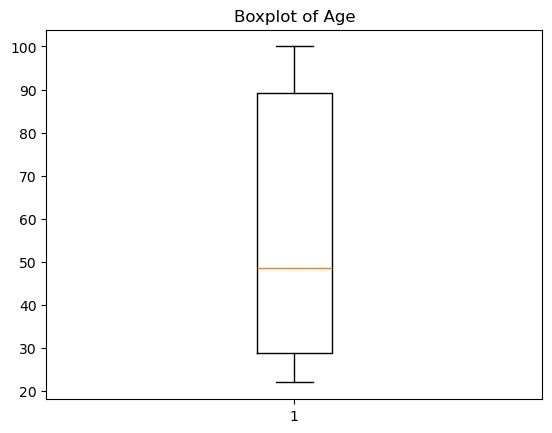

In [10]:
#3. Visualization Using Boxplot
import matplotlib.pyplot as plt

plt.boxplot(df["Age"])
plt.title("Boxplot of Age")
plt.show()